# USGS Data Analysis and Comparison

This notebook analyzes new USGS stream and groundwater data and compares it with existing Santa Barbara County sites.
It processes two text files: stream sites and groundwater sites.


## Imports and setup

In [16]:
# Standard imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import re

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries loaded successfully")

Libraries loaded successfully


## Load USGS data files

In [ ]:
# ==== Load USGS Stream and Groundwater Data ====
print("=== LOADING USGS DATA FILES ===")
from pathlib import Path

stream_file = Path(r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_usgs\sb_streams.txt")
groundwater_file = Path(r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_usgs\entire_usa_2022.txt")  

# Function to safely load text files with multiple encoding attempts
def load_text_file(filepath, delimiter='\t'):
    """Load text file with fallback encoding options"""
    encodings = ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']
    
    for encoding in encodings:
        try:
            df = pd.read_csv(filepath, delimiter=delimiter, encoding=encoding, low_memory=False)
            print(f"Successfully loaded {filepath} with {encoding} encoding")
            return df
        except UnicodeDecodeError:
            continue
        except Exception as e:
            print(f"Error loading {filepath} with {encoding}: {e}")
            continue
    
    raise ValueError(f"Could not load {filepath} with any encoding")

# Load the files (uncomment when you have the actual file paths)
stream_data = load_text_file(stream_file)
groundwater_data = load_text_file(groundwater_file)

# Once loaded, display basic info
if stream_data is not None:
    print(f"\nStream data shape: {stream_data.shape}")
    print("Stream data columns:")
    print(stream_data.columns.tolist())
    display(stream_data.head(3))

if groundwater_data is not None:
    print(f"\nGroundwater data shape: {groundwater_data.shape}")
    print("Groundwater data columns:")
    print(groundwater_data.columns.tolist())
    display(groundwater_data.head(3))

=== LOADING USGS DATA FILES ===
Successfully loaded C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_usgs\sb_streams.txt with utf-8 encoding


## Data exploration and coordinate identification

In [3]:
# ==== Explore USGS Data Structure ====
print("=== USGS DATA EXPLORATION ===")

def explore_dataframe(df, name):
    """Explore dataframe structure and identify potential coordinate columns"""
    if df is None:
        print(f"{name}: No data loaded yet")
        return
    
    print(f"\n{name.upper()} DATA:")
    print(f"Shape: {df.shape}")
    print(f"Columns ({len(df.columns)}): {df.columns.tolist()}")
    
    # Look for coordinate columns
    coord_patterns = {
        'latitude': r'(?i)lat|latitude|y_coord|northing|lat_dd',
        'longitude': r'(?i)lon|lng|longitude|x_coord|easting|long_dd|lon_dd'
    }
    
    potential_coords = {}
    for coord_type, pattern in coord_patterns.items():
        matches = [col for col in df.columns if re.search(pattern, str(col))]
        if matches:
            potential_coords[coord_type] = matches
    
    if potential_coords:
        print(f"Potential coordinate columns:")
        for coord_type, cols in potential_coords.items():
            print(f"  {coord_type}: {cols}")
    else:
        print("No obvious coordinate columns found - manual inspection needed")
    
    # Show data types
    print(f"\nData types:")
    for col in df.columns[:10]:  # First 10 columns
        dtype = df[col].dtype
        non_null = df[col].notna().sum()
        print(f"  {col}: {dtype} ({non_null:,}/{len(df):,} non-null)")
    
    if len(df.columns) > 10:
        print(f"  ... and {len(df.columns) - 10} more columns")
    
    # Show sample data
    print(f"\nFirst few rows:")
    return df.head()

# Explore both datasets
if stream_data is not None or groundwater_data is not None:
    stream_sample = explore_dataframe(stream_data, "stream")
    if stream_sample is not None:
        display(stream_sample)
    
    groundwater_sample = explore_dataframe(groundwater_data, "groundwater")
    if groundwater_sample is not None:
        display(groundwater_sample)
else:
    print("Load the data files first by updating the file paths in the previous cell")

=== USGS DATA EXPLORATION ===

STREAM DATA:
Shape: (570, 15)
Columns (15): ['agency_cd', 'site_no', 'station_nm', 'site_tp_cd', 'dec_lat_va', 'dec_long_va', 'coord_acy_cd', 'dec_coord_datum_cd', 'county_cd', 'peak_begin_date', 'peak_end_date', 'peak_count_nu', 'gw_begin_date', 'gw_end_date', 'gw_count_nu']
Potential coordinate columns:
  latitude: ['dec_lat_va']
  longitude: ['dec_long_va']

Data types:
  agency_cd: object (570/570 non-null)
  site_no: int64 (570/570 non-null)
  station_nm: object (570/570 non-null)
  site_tp_cd: object (570/570 non-null)
  dec_lat_va: float64 (570/570 non-null)
  dec_long_va: float64 (570/570 non-null)
  coord_acy_cd: object (570/570 non-null)
  dec_coord_datum_cd: object (570/570 non-null)
  county_cd: int64 (570/570 non-null)
  peak_begin_date: object (570/570 non-null)
  ... and 5 more columns

First few rows:


,agency_cd,site_no,station_nm,site_tp_cd,dec_lat_va,dec_long_va,coord_acy_cd,dec_coord_datum_cd,county_cd,peak_begin_date,peak_end_date,peak_count_nu,gw_begin_date,gw_end_date,gw_count_nu
0,USGS,9423350,CARUTHERS C NR IVANPAH CA,ST,35.245006,-115.298989,5,NAD83,71,1963-10-18,2024-02-20,61,--,--,0
1,USGS,10253000,GOURD C NR LUDLOW CA,ST,34.676379,-116.023062,F,NAD83,71,1959,2024,62,--,--,0
2,USGS,10254050,SALT C NR MECCA,ST,33.446984,-115.843323,F,NAD83,65,1962-09-27,1990-06-09,29,--,--,0
3,USGS,10255550,NEW R NR WESTMORLAND CA,ST,33.104772,-115.664426,F,NAD83,25,1962-01-25,2024-01-24,63,--,--,0
4,USGS,10256500,SNOW C NR WHITE WATER CA,ST,33.870579,-116.681127,F,NAD83,65,1922-12-14,2024-02-05,73,--,--,0



GROUNDWATER DATA:
Shape: (10508313, 34)
Columns (34): ['agency_cd.x', 'site_no', 'station_nm', 'dec_lat_va', 'dec_long_va', 'coord_acy_cd', 'dec_coord_datum_cd', 'state_cd', 'alt_va', 'alt_acy_va', 'alt_datum_cd', 'well_depth_va', 'hole_depth_va', 'id.x', 'agency_cd.y', 'site_tp_cd', 'lev_dt', 'lev_tm', 'lev_tz_cd', 'lev_va', 'sl_lev_va', 'sl_datum_cd', 'lev_status_cd', 'lev_agency_cd', 'lev_dt_acy_cd', 'lev_acy_cd', 'lev_src_cd', 'lev_meth_cd', 'lev_age_cd', 'id.y', 'level_date', 'level_decimal_date', 'level_month', 'level_year']
Potential coordinate columns:
  latitude: ['dec_lat_va']
  longitude: ['dec_long_va']

Data types:
  agency_cd.x: object (10,288,525/10,508,313 non-null)
  site_no: int64 (10,508,313/10,508,313 non-null)
  station_nm: object (10,288,521/10,508,313 non-null)
  dec_lat_va: float64 (10,283,740/10,508,313 non-null)
  dec_long_va: float64 (10,283,740/10,508,313 non-null)
  coord_acy_cd: object (10,284,022/10,508,313 non-null)
  dec_coord_datum_cd: object (10,283,

,agency_cd.x,site_no,station_nm,dec_lat_va,dec_long_va,coord_acy_cd,dec_coord_datum_cd,state_cd,alt_va,alt_acy_va,alt_datum_cd,well_depth_va,hole_depth_va,id.x,agency_cd.y,site_tp_cd,lev_dt,lev_tm,lev_tz_cd,lev_va,sl_lev_va,sl_datum_cd,lev_status_cd,lev_agency_cd,lev_dt_acy_cd,lev_acy_cd,lev_src_cd,lev_meth_cd,lev_age_cd,id.y,level_date,level_decimal_date,level_month,level_year
0,USGS,515150176385301,MRP-MW14 ADAK AK SC09619514B,51.862510,-176.650529,M,NAD83,2.0,5.0,30.0,NGVD29,NaN,NaN,ak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USGS,515155176383401,ADAK ISLAND TEST HOLE FPP12,51.863899,-176.645251,5,NAD83,2.0,30.0,5.0,NGVD29,25,25,ak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USGS,515155176383901,ADAK ISLAND WELL 01-118,51.863899,-176.646640,5,NAD83,2.0,30.0,5.0,NGVD29,25,25,ak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,USGS,515155176384001,ADAK ISLAND TEST HOLE FPP11,51.863899,-176.646918,5,NAD83,2.0,30.0,5.0,NGVD29,25,25,ak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USGS,515155176384101,ADAK ISLAND TEST HOLE FPP10,51.863899,-176.647196,5,NAD83,2.0,30.0,5.0,NGVD29,25,25,ak,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Coordinate processing and standardization

In [4]:
# ==== Process and Standardize Coordinates ====
print("=== COORDINATE PROCESSING ===")

def process_usgs_coordinates(df, name, lat_col=None, lon_col=None):
    """Process coordinates in USGS data"""
    if df is None:
        print(f"{name}: No data to process")
        return None
    
    print(f"\nProcessing {name} coordinates...")
    
    # If columns not specified, try to auto-detect
    if lat_col is None or lon_col is None:
        print("Coordinate columns not specified - attempting auto-detection")
        
        # Common USGS column patterns
        lat_patterns = [r'(?i)dec_lat', r'(?i)latitude', r'(?i)lat_dd', r'(?i)lat']
        lon_patterns = [r'(?i)dec_long', r'(?i)longitude', r'(?i)long_dd', r'(?i)lon_dd', r'(?i)lon']
        
        for pattern in lat_patterns:
            matches = [col for col in df.columns if re.search(pattern, str(col))]
            if matches:
                lat_col = matches[0]
                break
        
        for pattern in lon_patterns:
            matches = [col for col in df.columns if re.search(pattern, str(col))]
            if matches:
                lon_col = matches[0]
                break
        
        if lat_col and lon_col:
            print(f"Auto-detected coordinates: lat='{lat_col}', lon='{lon_col}'")
        else:
            print("Could not auto-detect coordinate columns. Please specify manually.")
            return None
    
    # Create working copy
    df_processed = df.copy()
    
    # Convert coordinates to numeric
    df_processed['lat_combined'] = pd.to_numeric(df_processed[lat_col], errors='coerce')
    df_processed['lon_combined'] = pd.to_numeric(df_processed[lon_col], errors='coerce')
    
    # Check for coordinate issues
    initial_count = len(df_processed)
    valid_coords = df_processed['lat_combined'].between(-90, 90) & df_processed['lon_combined'].between(-180, 180)
    
    print(f"Coordinate validation:")
    print(f"  Initial rows: {initial_count:,}")
    print(f"  Valid coordinates: {valid_coords.sum():,}")
    print(f"  Invalid/missing coordinates: {(~valid_coords).sum():,}")
    
    # Filter to valid coordinates
    df_processed = df_processed[valid_coords].copy()
    
    # Add data source identifier
    df_processed['data_source'] = f'USGS_{name}'
    
    # Show coordinate ranges
    if not df_processed.empty:
        print(f"Coordinate ranges:")
        print(f"  Latitude: {df_processed['lat_combined'].min():.6f} to {df_processed['lat_combined'].max():.6f}")
        print(f"  Longitude: {df_processed['lon_combined'].min():.6f} to {df_processed['lon_combined'].max():.6f}")
    
    return df_processed

# Process both datasets (update column names as needed after data exploration)
# PLACEHOLDER - UPDATE THESE COLUMN NAMES BASED ON YOUR ACTUAL DATA
STREAM_LAT_COL = 'dec_lat_va' 
STREAM_LON_COL = 'dec_long_va'  
GROUNDWATER_LAT_COL = 'dec_lat_va' 
GROUNDWATER_LON_COL = 'dec_long_va' 

# Process the data
stream_processed = process_usgs_coordinates(stream_data, 'stream', STREAM_LAT_COL, STREAM_LON_COL)
groundwater_processed = process_usgs_coordinates(groundwater_data, 'groundwater', GROUNDWATER_LAT_COL, GROUNDWATER_LON_COL)


=== COORDINATE PROCESSING ===

Processing stream coordinates...
Coordinate validation:
  Initial rows: 570
  Valid coordinates: 570
  Invalid/missing coordinates: 0
Coordinate ranges:
  Latitude: 32.637557 to 42.006236
  Longitude: -124.283354 to -115.106927

Processing groundwater coordinates...
Coordinate validation:
  Initial rows: 10,508,313
  Valid coordinates: 10,283,740
  Invalid/missing coordinates: 224,573
Coordinate ranges:
  Latitude: -14.347825 to 71.341808
  Longitude: -176.650529 to 174.116118


## Create GeoDataFrames and filter to study area

In [5]:
# ==== Create GeoDataFrames and Filter to Study Area ====
print("=== CREATING GEODATAFRAMES ===")

def create_usgs_geodataframe(df_processed, name):
    """Create GeoDataFrame from processed USGS data"""
    if df_processed is None or df_processed.empty:
        print(f"{name}: No processed data available")
        return None
    
    print(f"Creating {name} GeoDataFrame...")
    
    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df_processed,
        geometry=gpd.points_from_xy(df_processed['lon_combined'], df_processed['lat_combined']),
        crs="EPSG:4326"
    )
    
    print(f"  Created GeoDataFrame with {len(gdf):,} points")
    
    return gdf

# Create GeoDataFrames
gdf_stream = create_usgs_geodataframe(stream_processed, 'stream')
gdf_groundwater = create_usgs_geodataframe(groundwater_processed, 'groundwater')

# Filter to Santa Barbara County area (reuse county boundary from previous work)
print("\n=== FILTERING TO SANTA BARBARA COUNTY ===")

# Load Santa Barbara County boundary
sb_county_shapefile = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_shapefile\sb_county_shp.shp"

try:
    sb_county = gpd.read_file(sb_county_shapefile)
    if sb_county.crs is None or sb_county.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
        sb_county = sb_county.to_crs("EPSG:4326")
    
    sb_county_geom = sb_county.union_all() if hasattr(sb_county, "union_all") else sb_county.unary_union
    SB_COUNTY_GDF = gpd.GeoSeries([sb_county_geom], crs="EPSG:4326")
    
    print(f"Loaded Santa Barbara County boundary")
    
    # Filter each dataset to Santa Barbara County
    def filter_to_sb_county(gdf, name):
        if gdf is None:
            return None
        
        within_sb = gdf.within(sb_county_geom)
        gdf_sb = gdf.loc[within_sb].copy()
        
        print(f"{name.capitalize()} sites:")
        print(f"  Total: {len(gdf):,}")
        print(f"  In Santa Barbara County: {len(gdf_sb):,}")
        print(f"  Outside county: {(~within_sb).sum():,}")
        
        return gdf_sb
    
    gdf_stream_sb = filter_to_sb_county(gdf_stream, 'stream')
    gdf_groundwater_sb = filter_to_sb_county(gdf_groundwater, 'groundwater')
    
except FileNotFoundError:
    print(f"Santa Barbara County shapefile not found: {sb_county_shapefile}")
    print("Using full datasets without county filtering")
    gdf_stream_sb = gdf_stream
    gdf_groundwater_sb = gdf_groundwater
    SB_COUNTY_GDF = None

# Show summary
print("\n=== USGS DATA SUMMARY ===")
if gdf_stream_sb is not None:
    print(f"Stream sites in study area: {len(gdf_stream_sb):,}")
if gdf_groundwater_sb is not None:
    print(f"Groundwater sites in study area: {len(gdf_groundwater_sb):,}")

total_usgs = 0
if gdf_stream_sb is not None:
    total_usgs += len(gdf_stream_sb)
if gdf_groundwater_sb is not None:
    total_usgs += len(gdf_groundwater_sb)

print(f"Total USGS sites in study area: {total_usgs:,}")

=== CREATING GEODATAFRAMES ===
Creating stream GeoDataFrame...
  Created GeoDataFrame with 570 points
Creating groundwater GeoDataFrame...
  Created GeoDataFrame with 10,283,740 points

=== FILTERING TO SANTA BARBARA COUNTY ===
Loaded Santa Barbara County boundary
Stream sites:
  Total: 570
  In Santa Barbara County: 32
  Outside county: 538
Groundwater sites:
  Total: 10,283,740
  In Santa Barbara County: 184,312
  Outside county: 10,099,428

=== USGS DATA SUMMARY ===
Stream sites in study area: 32
Groundwater sites in study area: 184,312
Total USGS sites in study area: 184,344


In [ ]:
# ==== Simple Summary of SB Groundwater Sites (1810-1979) ====
print("=== CREATING GROUNDWATER SITES SUMMARY (1810-1979) ===")

if gdf_groundwater_sb is not None and not gdf_groundwater_sb.empty:
    print(f"Starting with {len(gdf_groundwater_sb):,} groundwater measurements")
    
    # Apply date filter first (1820-1979)
    if 'level_year' in gdf_groundwater_sb.columns:
        date_mask = gdf_groundwater_sb['level_year'].between(1810, 1979)
        gdf_filtered = gdf_groundwater_sb[date_mask].copy()
        
        print(f"After 1810-1979 filter: {len(gdf_filtered):,} measurements")
        print(f"Removed: {len(gdf_groundwater_sb) - len(gdf_filtered):,} measurements outside date range")
        
        if len(gdf_filtered) == 0:
            print("WARNING: No data remaining after date filtering!")
        
    else:
        print("WARNING: No 'level_year' column found - cannot apply date filter")
        gdf_filtered = gdf_groundwater_sb.copy()
    
    # Group by site_no and get basic info + year ranges
    site_summary = gdf_filtered.groupby('site_no').agg({
        'station_nm': 'first',
        'dec_lat_va': 'first', 
        'dec_long_va': 'first',
        'level_year': ['min', 'max', 'count']
    }).reset_index()
    
    # Flatten column names
    site_summary.columns = ['site_no', 'station_name', 'latitude', 'longitude', 
                           'start_year', 'end_year', 'total_measurements']
    
    # Remove rows where we couldn't get year data
    site_summary = site_summary.dropna(subset=['start_year', 'end_year'])
    
    print(f"Created summary for {len(site_summary):,} unique sites with 1810-1979 data")
    
    # Export to CSV
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    
    csv_path = output_dir / "sb_groundwater_sites_1810_1979.csv"
    site_summary.to_csv(csv_path, index=False)
    
    print(f"Exported to: {csv_path}")
    print("\nSample of data:")
    display(site_summary.head())
    
    # Quick stats
    print(f"\nYear range statistics (1810-1979 data only):")
    print(f"  Earliest measurement: {int(site_summary['start_year'].min())}")
    print(f"  Latest measurement: {int(site_summary['end_year'].max())}")
    print(f"  Average measurements per site: {site_summary['total_measurements'].mean():.1f}")
    
else:
    print("No groundwater data available")

## Load existing Santa Barbara data for comparison

In [6]:
# ==== Load Existing Santa Barbara County Data for Comparison (UPDATED FOR ADDITIONAL DATA) ====
print("=== LOADING EXISTING SB COUNTY DATA ===")

# Load enhanced dataset from artifacts instead of hardcoded CSV
from artifacts_io import load_artifacts

# Load artifacts that include both main and additional data
tables, meta, run_dir = load_artifacts(out_dir="artifacts")
run_id = os.path.basename(run_dir)
print(f"Loaded artifacts from: {run_dir}")

# Get the combined dataset
if "df_combined" in tables:
    df_sb_all = tables["df_combined"].copy()
    print(f"Using df_combined: {len(df_sb_all):,} total sites")
elif "df" in tables:
    df_sb_all = tables["df"].copy()
    print(f"Using df: {len(df_sb_all):,} total sites")
else:
    # Use the largest table
    everything_key = max(tables, key=lambda k: tables[k].shape[0])
    df_sb_all = tables[everything_key].copy()
    print(f"Using {everything_key}: {len(df_sb_all):,} total sites")

# Filter to Santa Barbara County using geometric boundaries (same as streamflow script)
sb_county_shapefile = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_shapefile\sb_county_shp.shp"

try:
    sb_county = gpd.read_file(sb_county_shapefile)
    if sb_county.crs is None or sb_county.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
        sb_county = sb_county.to_crs("EPSG:4326")
    
    sb_county_geom = sb_county.union_all() if hasattr(sb_county, "union_all") else sb_county.unary_union
    
    # Create GeoDataFrame for filtering
    coord_cols = ['lon_combined', 'lat_combined'] if 'lon_combined' in df_sb_all.columns else ['longitude', 'latitude']
    df_sb_all_gdf = gpd.GeoDataFrame(
        df_sb_all,
        geometry=gpd.points_from_xy(df_sb_all[coord_cols[0]], df_sb_all[coord_cols[1]]),
        crs="EPSG:4326"
    )
    
    # Filter to Santa Barbara County only
    within_sb = df_sb_all_gdf.within(sb_county_geom)
    df_sb_existing = df_sb_all.loc[within_sb].copy()
    
    print(f"Filtered from {len(df_sb_all):,} total sites to {len(df_sb_existing):,} Santa Barbara County sites")
    
    # Create GeoDataFrame for the filtered data
    gdf_sb_existing = gpd.GeoDataFrame(
        df_sb_existing,
        geometry=gpd.points_from_xy(df_sb_existing[coord_cols[0]], df_sb_existing[coord_cols[1]]),
        crs="EPSG:4326"
    )
    
    print(f"Loaded existing Santa Barbara data: {len(gdf_sb_existing):,} sites")
    
    # Add data source identifier
    gdf_sb_existing['data_source'] = 'Historical_USGS'
    
    # Check for data source information from the enhanced dataset
    if 'data_source' in df_sb_existing.columns:
        print("Santa Barbara data source breakdown:")
        print(df_sb_existing['data_source'].value_counts())
    
    print("Water type distribution in existing data:")
    if 'water_type_clean' in gdf_sb_existing.columns:
        print(gdf_sb_existing['water_type_clean'].value_counts())

except FileNotFoundError:
    print(f"Could not find Santa Barbara County shapefile: {sb_county_shapefile}")
    raise

# Create comparison summary
print("\n=== DATA COMPARISON SUMMARY ===")
print(f"New USGS stream sites: {len(gdf_stream_sb) if gdf_stream_sb is not None else 0:,}")
print(f"New USGS groundwater sites: {len(gdf_groundwater_sb) if gdf_groundwater_sb is not None else 0:,}")
print(f"Existing historical sites: {len(gdf_sb_existing) if gdf_sb_existing is not None else 0:,}")
print(f"Total sites for analysis: {(len(gdf_stream_sb) if gdf_stream_sb is not None else 0) + (len(gdf_groundwater_sb) if gdf_groundwater_sb is not None else 0) + (len(gdf_sb_existing) if gdf_sb_existing is not None else 0):,}")

# ==== PROPER EXTENT CALCULATION (Same as working script) ====
print("\n=== CALCULATING PROPER MAP EXTENT ===")

# Combine all data for extent calculation
all_mapping_data = []
if gdf_stream_sb is not None and len(gdf_stream_sb) > 0:
    all_mapping_data.append(gdf_stream_sb)
if gdf_groundwater_sb is not None and len(gdf_groundwater_sb) > 0:
    all_mapping_data.append(gdf_groundwater_sb)
if gdf_sb_existing is not None and len(gdf_sb_existing) > 0:
    all_mapping_data.append(gdf_sb_existing)

if all_mapping_data:
    # Combine all data to get proper bounds
    combined_data = gpd.GeoDataFrame(pd.concat(all_mapping_data, ignore_index=True))
    
    # Get bounds from the ACTUAL DATA (not the county shapefile)
    minx, miny, maxx, maxy = combined_data.total_bounds
    
    # Calculate proportional padding (same as working script)
    pad_lon = max(0.01, (maxx - minx) * 0.15)  # 15% padding
    pad_lat = max(0.01, (maxy - miny) * 0.15)
    
    # Set consistent extent variables
    SB_XMIN, SB_YMIN, SB_XMAX, SB_YMAX = (
        minx - pad_lon, 
        miny - pad_lat, 
        maxx + pad_lon, 
        maxy + pad_lat
    )
    
    print(f"Data extent: {minx:.3f}, {miny:.3f}, {maxx:.3f}, {maxy:.3f}")
    print(f"Map extent with padding: {SB_XMIN:.3f}, {SB_YMIN:.3f}, {SB_XMAX:.3f}, {SB_YMAX:.3f}")
else:
    print("Warning: No data found for extent calculation")
    # Default Santa Barbara area including Channel Islands
    SB_XMIN, SB_YMIN, SB_XMAX, SB_YMAX = (-120.8, 33.8, -119.4, 34.9)
    

=== LOADING EXISTING SB COUNTY DATA ===
Loaded artifacts from: artifacts\run_20250901_113434
Using df_combined: 109,626 total sites
Filtered from 109,626 total sites to 6,786 Santa Barbara County sites
Loaded existing Santa Barbara data: 6,786 sites
Santa Barbara data source breakdown:
data_source
main          4992
additional    1794
Name: count, dtype: int64
Water type distribution in existing data:
water_type_clean
Groundwater          3251
Stream discharge     2516
Springs               506
Irrigation            209
Reservoir             111
Precipitation          60
Not water related      24
Water quality           5
Name: count, dtype: int64

=== DATA COMPARISON SUMMARY ===
New USGS stream sites: 32
New USGS groundwater sites: 184,312
Existing historical sites: 6,786
Total sites for analysis: 191,130

=== CALCULATING PROPER MAP EXTENT ===
Data extent: -120.657, 34.000, -119.444, 35.096
Map extent with padding: -120.839, 33.836, -119.262, 35.261


## Plots to compare data

=== CREATING GROUNDWATER COMPARISON MAP ===
Restored groundwater sites: 3,251
NWIS USGS groundwater sites: 6,548
Saved: output\groundwater_comparison_historical_vs_usgs.png


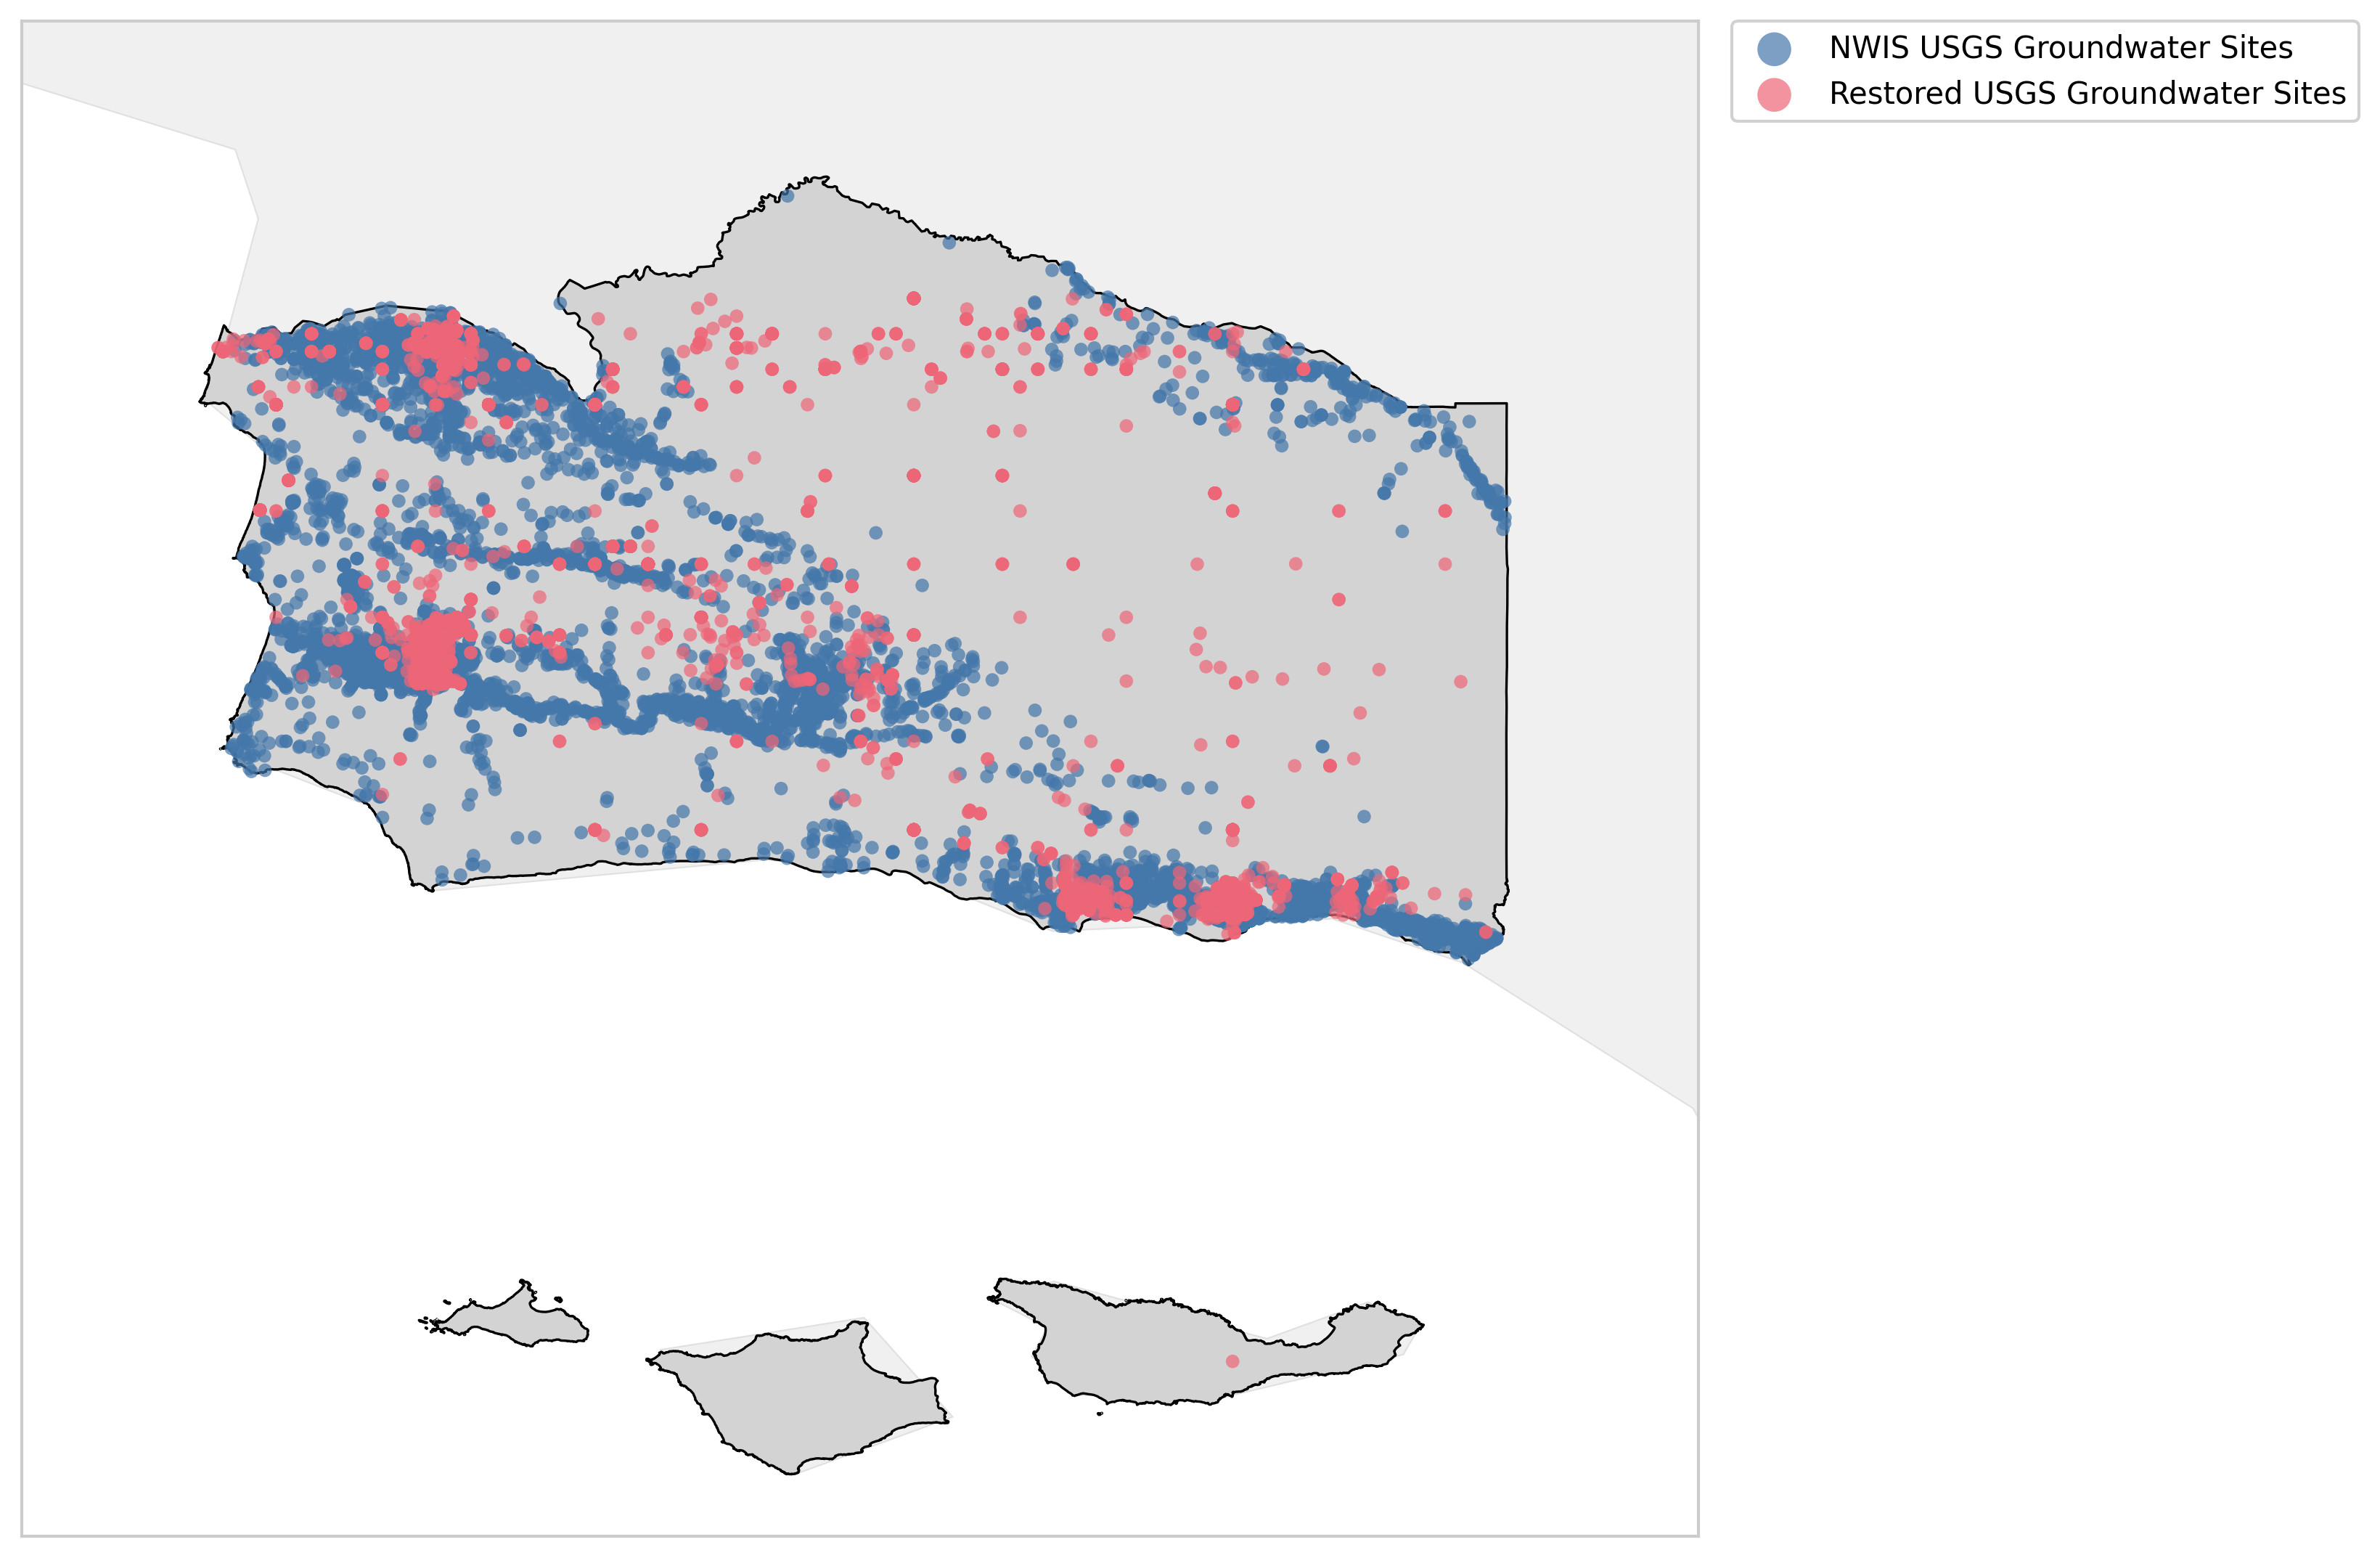

In [9]:
# ==== Groundwater Comparison Map: Historical vs New USGS ====
import os
import matplotlib.pyplot as plt
import geopandas as gpd

print("=== CREATING GROUNDWATER COMPARISON MAP ===")

# Check we have both datasets
if gdf_sb_existing is None:
    print("ERROR: No existing SB data loaded")
elif gdf_groundwater_sb is None:
    print("ERROR: No new USGS groundwater data loaded") 
else:
    # Filter existing data to just groundwater sites
    historical_gw = gdf_sb_existing[gdf_sb_existing['water_type_clean'] == 'Groundwater'].copy()
    
    # For new USGS data, we'll use the filtered 1810-1979 data if available
    if 'gdf_filtered' in locals() and gdf_filtered is not None:
        # Use the date-filtered data and group by site to avoid duplicates
        new_gw_summary = gdf_filtered.groupby('site_no').agg({
            'dec_lat_va': 'first',
            'dec_long_va': 'first',
            'station_nm': 'first'
        }).reset_index()
        
        # Create GeoDataFrame for new sites
        new_gw = gpd.GeoDataFrame(
            new_gw_summary,
            geometry=gpd.points_from_xy(new_gw_summary['dec_long_va'], new_gw_summary['dec_lat_va']),
            crs="EPSG:4326"
        )
    else:
        # Fallback: use all groundwater data but group by site
        new_gw_summary = gdf_groundwater_sb.groupby('site_no').agg({
            'dec_lat_va': 'first',
            'dec_long_va': 'first', 
            'station_nm': 'first'
        }).reset_index()
        
        new_gw = gpd.GeoDataFrame(
            new_gw_summary,
            geometry=gpd.points_from_xy(new_gw_summary['dec_long_va'], new_gw_summary['dec_lat_va']),
            crs="EPSG:4326"
        )
    
    print(f"Restored groundwater sites: {len(historical_gw):,}")
    print(f"NWIS USGS groundwater sites: {len(new_gw):,}")

    
    # Calculate aspect ratio based on data bounds (not arbitrary)
    width = SB_XMAX - SB_XMIN
    height = SB_YMAX - SB_YMIN
    aspect_ratio = width / height
    fig, ax = plt.subplots(figsize=(10, 10/aspect_ratio), dpi=300)
    
    # Add California state context
    try:
        ca_context_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\ca_shapefile\ca_poly.shp"
        if os.path.exists(ca_context_path):
            ca_context = gpd.read_file(ca_context_path).to_crs("EPSG:4326")
            ca_context_geom = ca_context.union_all() if hasattr(ca_context, "union_all") else ca_context.unary_union
            gpd.GeoSeries([ca_context_geom], crs="EPSG:4326").plot(
                ax=ax,
                color="#f0f0f0",
                edgecolor="#e0e0e0", 
                linewidth=0.5,
                zorder=0
            )
    except Exception:
        pass
    
    # Plot Santa Barbara County boundary
    if SB_COUNTY_GDF is not None:
        SB_COUNTY_GDF.plot(
            ax=ax,
            color="lightgray",
            edgecolor="black",
            linewidth=0.8,
            zorder=1
        )
    
    # Plot new USGS groundwater sites (bottom layer)  
    new_gw.plot(
        ax=ax,
        color='#4477AA',  # Blue from your colorblind-safe palette
        markersize=20,
        alpha=0.7, 
        edgecolor='none',
        zorder=2,
        label='NWIS USGS Groundwater Sites'
    )
    
    # Plot historical groundwater sites (top layer)
    historical_gw.plot(
        ax=ax,
        color='#EE6677',  # Red from your colorblind-safe palette
        markersize=20,
        alpha=0.7,
        edgecolor='none',
        zorder=3,
        label='Restored USGS Groundwater Sites'
    )
    
    # CONSISTENT extent setting (no arbitrary extensions)
    ax.set_xlim(SB_XMIN, SB_XMAX)
    ax.set_ylim(SB_YMIN, SB_YMAX)
    ax.set_aspect('equal')
    
    # Clean styling
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)
    
    # Add border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#cccccc')
        spine.set_linewidth(1.0)
    
    # Legend
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        markerscale=2.5,
        frameon=True,
        fancybox=True,
        framealpha=0.9
    )
    
    # Create output directory
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    
    # Save
    outfile = output_dir / "groundwater_comparison_historical_vs_usgs.png"
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    print(f"Saved: {outfile}")
    plt.show()

## Decadal plots of groundwater 

=== CREATING DECADAL GROUNDWATER MAP FROM ENHANCED DATASET ===
Loading NWIS USGS groundwater data...
Loaded NWIS USGS data: 3,794 sites
Using enhanced dataset from artifacts...
Historical groundwater sites from enhanced dataset: 3,251
Combining datasets...
Combined groundwater data: 7,045 sites
  - NWIS USGS: 3,794
  - Restored USGS: 3,251
Loaded Santa Barbara County boundary
Saved decadal groundwater map: output\groundwater_decadal_map_1860s_1970s.png


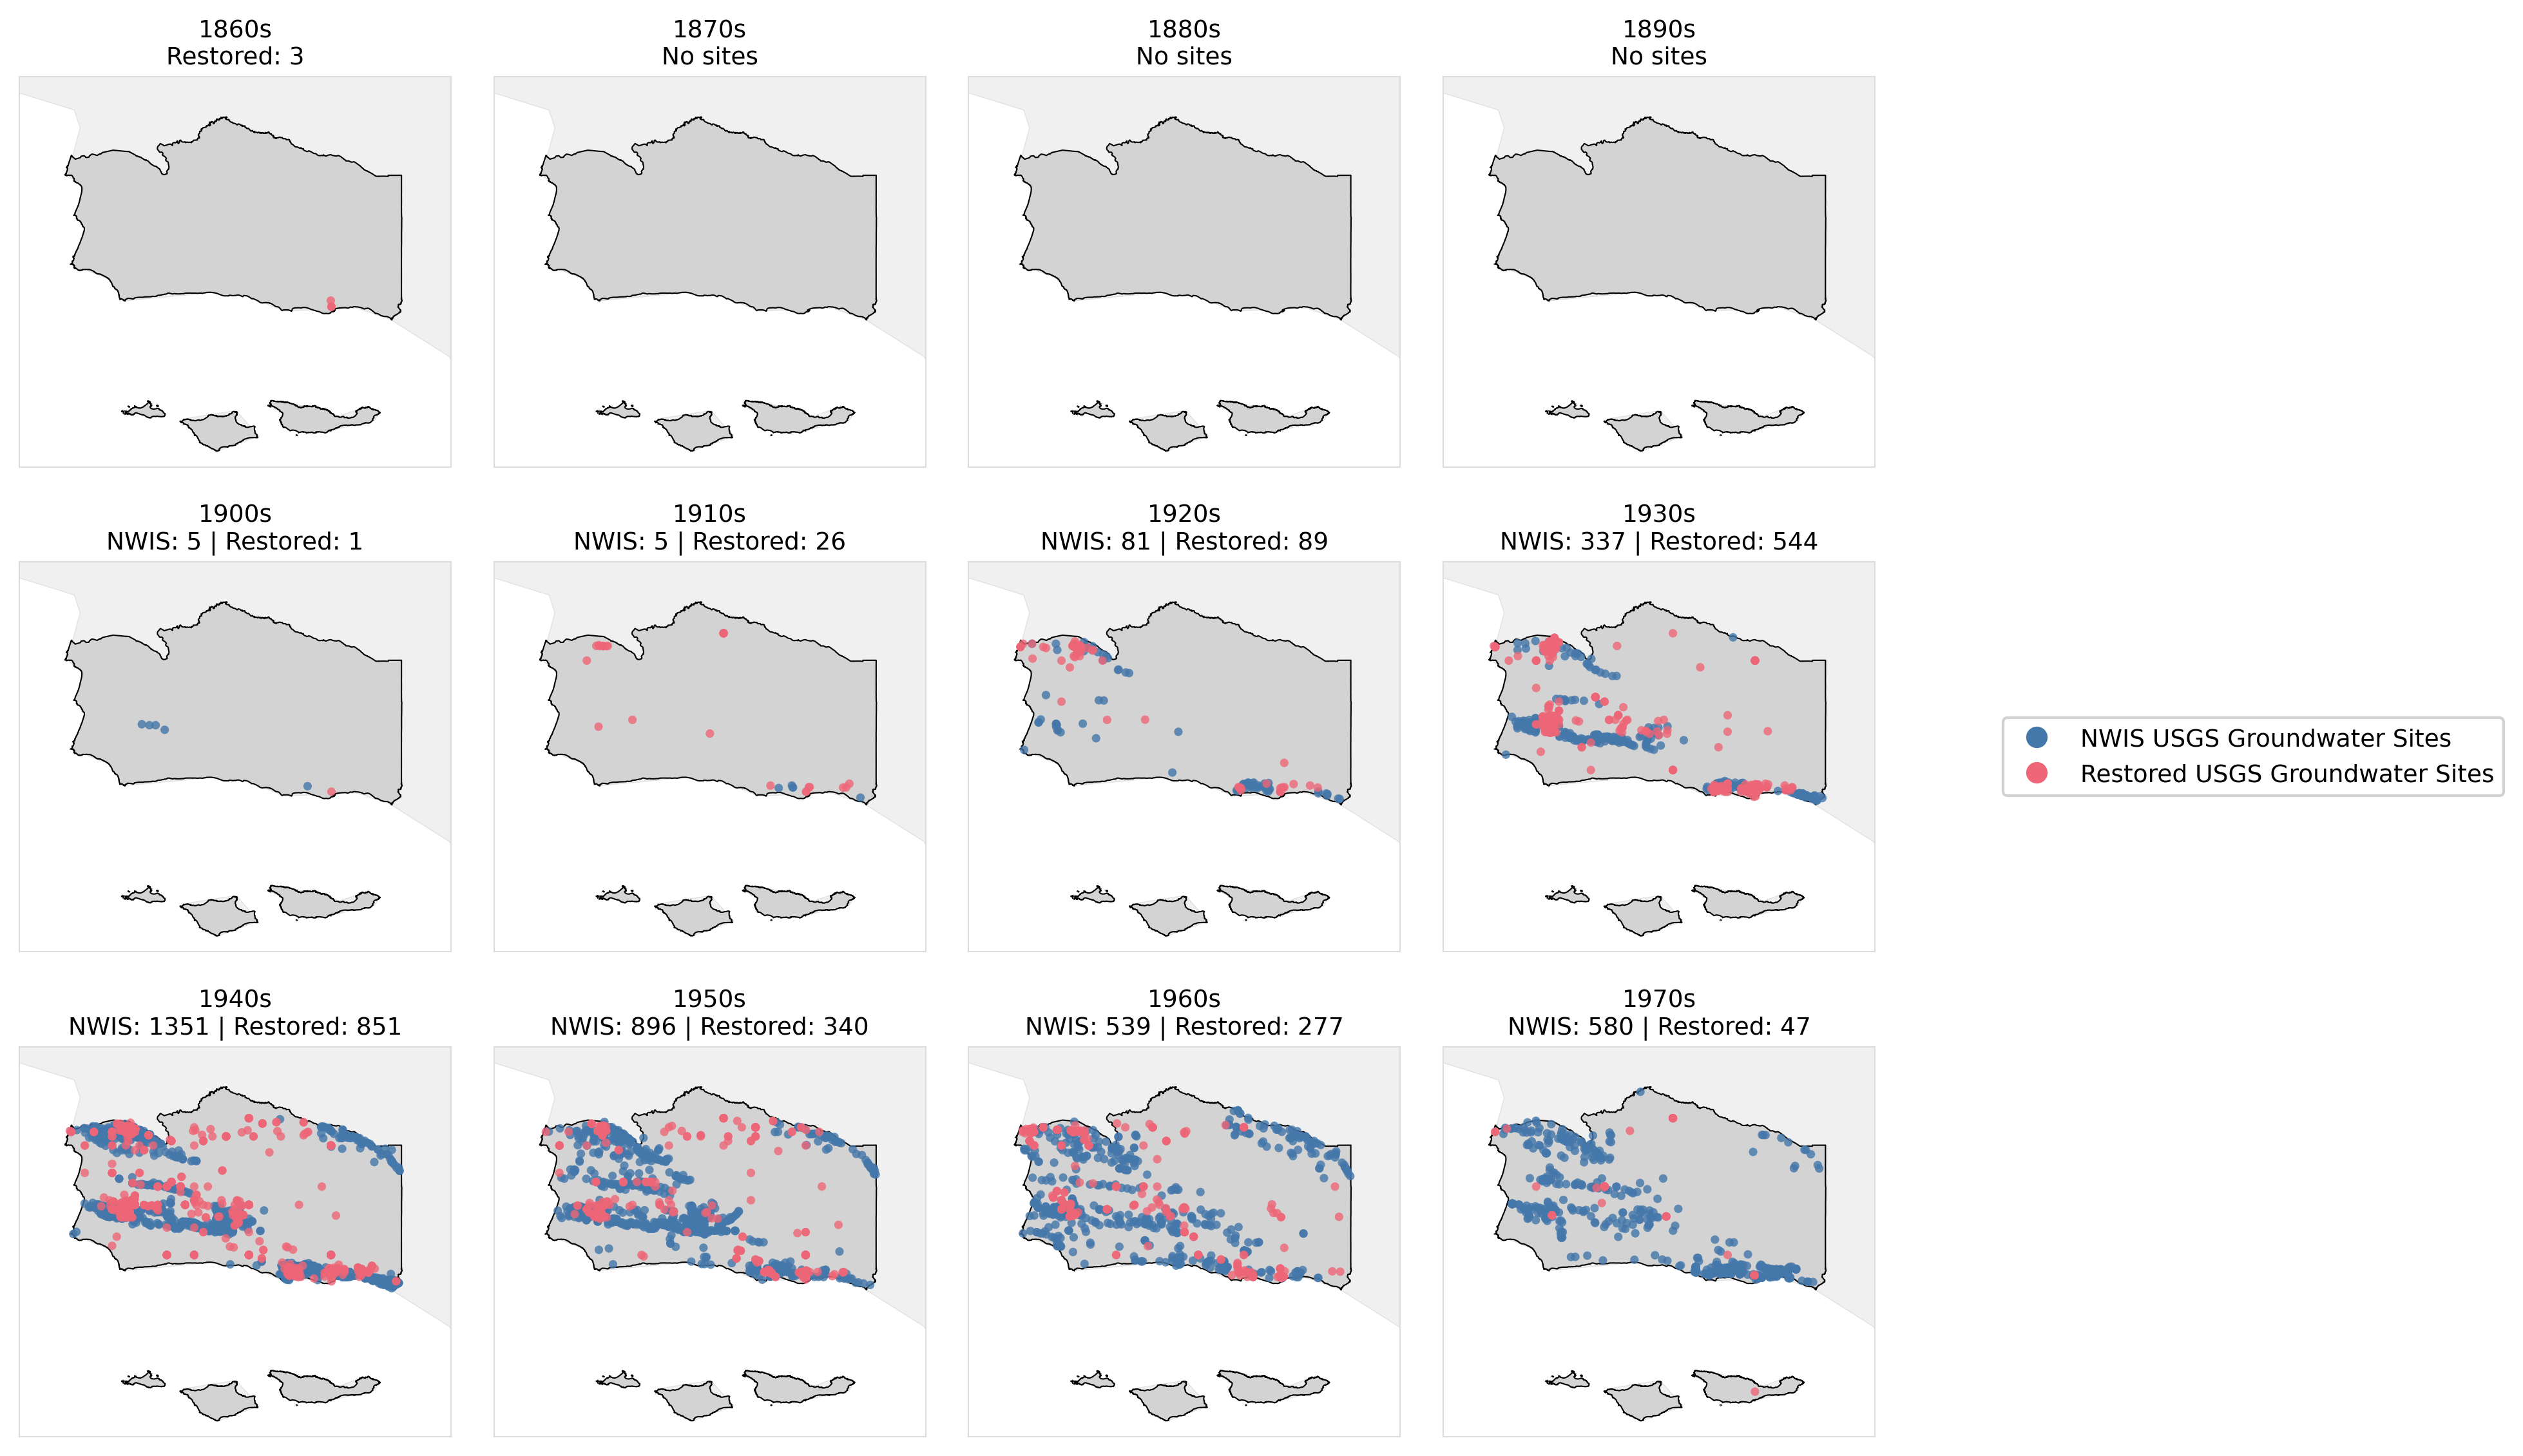


=== DECADAL SUMMARY ===
Sites by decade and data type:
data_type  NWIS USGS  Restored USGS
decade                             
1860.0             0              3
1900.0             5              1
1910.0             5             26
1920.0            81             89
1930.0           337            544
1940.0          1351            851
1950.0           896            340
1960.0           539            277
1970.0           580             47

Total sites by data type:
data_type
NWIS USGS        3794
Restored USGS    3251
Name: count, dtype: int64


In [15]:
# ==== Create Decadal Map for Groundwater Sites Only (Using Enhanced Dataset) ====
print("=== CREATING DECADAL GROUNDWATER MAP FROM ENHANCED DATASET ===")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
import os

# Define file paths
nwis_gw_csv = Path(r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\output\sb_groundwater_sites_1820_1979.csv")

try:
    # Load NWIS USGS groundwater data
    print("Loading NWIS USGS groundwater data...")
    nwis_gw_df = pd.read_csv(nwis_gw_csv)
    print(f"Loaded NWIS USGS data: {len(nwis_gw_df):,} sites")
    
    # Create GeoDataFrame for NWIS data
    nwis_gw_gdf = gpd.GeoDataFrame(
        nwis_gw_df,
        geometry=gpd.points_from_xy(nwis_gw_df['longitude'], nwis_gw_df['latitude']),
        crs="EPSG:4326"
    )
    
    # Add decade and data type columns for NWIS data
    # Check which column name is used for start year
    if 'start_year' in nwis_gw_gdf.columns:
        nwis_gw_gdf['decade'] = (nwis_gw_gdf['start_year'] // 10) * 10
    elif 'year_start' in nwis_gw_gdf.columns:
        nwis_gw_gdf['decade'] = (nwis_gw_gdf['year_start'] // 10) * 10
    else:
        print("Warning: No start year column found in NWIS data")
        nwis_gw_gdf['decade'] = 1940  # Default decade
    
    nwis_gw_gdf['data_type'] = 'NWIS USGS'
    
    # Use the enhanced dataset that was already loaded from artifacts (gdf_sb_existing)
    print("Using enhanced dataset from artifacts...")
    if 'gdf_sb_existing' in globals() and gdf_sb_existing is not None:
        # Filter to groundwater sites only
        historical_gw = gdf_sb_existing[gdf_sb_existing['water_type_clean'] == 'Groundwater'].copy()
        print(f"Historical groundwater sites from enhanced dataset: {len(historical_gw):,}")
        
        historical_gw_gdf = historical_gw.copy()
        
        # Add decade and data type columns for historical data
        # Check which column name is used for start year
        if 'start_year' in historical_gw_gdf.columns:
            historical_gw_gdf['decade'] = (historical_gw_gdf['start_year'] // 10) * 10
        elif 'year_start' in historical_gw_gdf.columns:
            historical_gw_gdf['decade'] = (historical_gw_gdf['year_start'] // 10) * 10
        else:
            print("Warning: No start year column found in historical data")
            historical_gw_gdf['decade'] = 1940  # Default decade
        
        historical_gw_gdf['data_type'] = 'Restored USGS'
        
    else:
        print("ERROR: Enhanced dataset not available. Make sure the previous cell ran successfully.")
        historical_gw_gdf = gpd.GeoDataFrame()
    
    # Combine both datasets
    print("Combining datasets...")
    
    # Select relevant columns for plotting
    nwis_subset = nwis_gw_gdf[['geometry', 'decade', 'data_type']].copy()
    historical_subset = historical_gw_gdf[['geometry', 'decade', 'data_type']].copy()
    
    # Combine into single GeoDataFrame
    all_gw_data = gpd.GeoDataFrame(pd.concat([nwis_subset, historical_subset], ignore_index=True))
    
    print(f"Combined groundwater data: {len(all_gw_data):,} sites")
    print(f"  - NWIS USGS: {len(nwis_subset):,}")
    print(f"  - Restored USGS: {len(historical_subset):,}")
    
    # Load Santa Barbara County boundary for plotting
    sb_county_shapefile = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_shapefile\sb_county_shp.shp"
    
    try:
        sb_county = gpd.read_file(sb_county_shapefile)
        if sb_county.crs is None or sb_county.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
            sb_county = sb_county.to_crs("EPSG:4326")
        
        sb_county_geom = sb_county.union_all() if hasattr(sb_county, "union_all") else sb_county.unary_union
        SB_COUNTY_GDF = gpd.GeoSeries([sb_county_geom], crs="EPSG:4326")
        print("Loaded Santa Barbara County boundary")
    except FileNotFoundError:
        print("Warning: County boundary file not found - will use data bounds")
        SB_COUNTY_GDF = None
    
    # Define decade range (1860s to 1970s)
    decades = list(range(1860, 1980, 10))
    
    # Set up the plot grid (4x3 = 12 decades)
    fig, axes = plt.subplots(3, 4, figsize=(12, 8), dpi=300)
    axes = axes.flatten()
    
    # Adjust spacing to match your version
    plt.subplots_adjust(
        left=0.05,
        bottom=0.05,
        right=0.85,  # Leave space for legend
        top=0.95,
        wspace=0.1,
        hspace=0.15
    )
    
    # Colors for different data types
    colors = {
        'Restored USGS': '#EE6677',  # Red
        'NWIS USGS': '#4477AA'      # Blue
    }

    
    # Plot each decade
    for i, decade in enumerate(decades):
        ax = axes[i]
        
        # Filter data for this decade
        decade_data = all_gw_data[all_gw_data['decade'] == decade]
        
        # Add California state context (if available)
        try:
            ca_context_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\ca_shapefile\ca_poly.shp"
            if os.path.exists(ca_context_path):
                ca_context = gpd.read_file(ca_context_path).to_crs("EPSG:4326")
                ca_context_geom = ca_context.union_all() if hasattr(ca_context, "union_all") else ca_context.unary_union
                gpd.GeoSeries([ca_context_geom], crs="EPSG:4326").plot(
                    ax=ax,
                    color="#f0f0f0",  # Very light gray for context
                    edgecolor="#e0e0e0",
                    linewidth=0.3,  # Thinner lines for small panels
                    zorder=0
                )
        except Exception:
            pass
        
        # Plot Santa Barbara County boundary
        if SB_COUNTY_GDF is not None:
            SB_COUNTY_GDF.plot(
                ax=ax,
                color="lightgray",
                edgecolor="black",
                linewidth=0.5,
                zorder=1
            )
        
        # Plot data for each type (NWIS first, then historical on top)
        for data_type, color in [('NWIS USGS', colors['NWIS USGS']), ('Restored USGS', colors['Restored USGS'])]:
            type_data = decade_data[decade_data['data_type'] == data_type]
            if len(type_data) > 0:
                type_data.plot(
                    ax=ax,
                    color=color,
                    markersize=10,  # Smaller markers like your version
                    alpha=0.8,
                    edgecolor='none',
                    linewidth=0,
                    zorder=2 if data_type == 'NWIS USGS' else 3
                )
        
        # Set extent
        # CONSISTENT extent setting (same for all panels)
        ax.set_xlim(SB_XMIN, SB_XMAX)
        ax.set_ylim(SB_YMIN, SB_YMAX)
        ax.set_aspect('equal')
        
        # Clean styling - match your version's lighter borders
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(False)
        
        # Light border like your version
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('#dddddd')  # Lighter gray like your version
            spine.set_linewidth(0.5)
        
    
         # Create detailed title with counts broken down by data type
        nwis_count = len(decade_data[decade_data['data_type'] == 'NWIS USGS'])
        restored_count = len(decade_data[decade_data['data_type'] == 'Restored USGS'])
        
        # Format title with breakdown
        if nwis_count > 0 and restored_count > 0:
            title = f"{decade}s\nNWIS: {nwis_count} | Restored: {restored_count}"
        elif nwis_count > 0:
            title = f"{decade}s\nNWIS: {nwis_count}"
        elif restored_count > 0:
            title = f"{decade}s\nRestored: {restored_count}"
        else:
            title = f"{decade}s\nNo sites"
        
        ax.set_title(title, fontsize=9, pad=5)
    
    # Add legend to match your version's positioning and styling
    from matplotlib.lines import Line2D
    
    legend_elements = [
        Line2D([0],[0], marker='o', linestyle='',
               markerfacecolor=colors['NWIS USGS'], 
               markeredgecolor='none',
               markersize=8, label='NWIS USGS Groundwater Sites'),
        Line2D([0],[0], marker='o', linestyle='',
               markerfacecolor=colors['Restored USGS'], 
               markeredgecolor='none',
               markersize=8, label='Restored USGS Groundwater Sites')
    ]
    
    fig.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(0.9, 0.5),  # Closer to plots like your version
        frameon=True,
        fancybox=True,
        framealpha=0.9,
        fontsize=9  # Smaller font like your version
    )
    
    # No overall title (removed to match your version)
    
    # Save the plot
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    
    outfile = output_dir / "groundwater_decadal_map_1860s_1970s.png"
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    print(f"Saved decadal groundwater map: {outfile}")
    
    plt.show()
    
    # Print summary statistics
    print(f"\n=== DECADAL SUMMARY ===")
    decade_summary = all_gw_data.groupby(['decade', 'data_type']).size().unstack(fill_value=0)
    print("Sites by decade and data type:")
    print(decade_summary)
    
    print(f"\nTotal sites by data type:")
    data_type_summary = all_gw_data['data_type'].value_counts()
    print(data_type_summary)

except FileNotFoundError as e:
    print(f"ERROR: Could not find required CSV file: {e}")
    print("Please check the file paths:")
    print(f"  NWIS GW data: {nwis_gw_csv}")
except Exception as e:
    print(f"ERROR: {e}")
    print("Please check that both CSV files exist and have the expected columns.")

## Cumulative measurements over time 

=== CREATING TWO-PANEL GROUNDWATER SITES TIMELINE ===
Using combined groundwater dataset from previous analysis...
Saved two-panel figure: output\groundwater_sites_two_panel.png


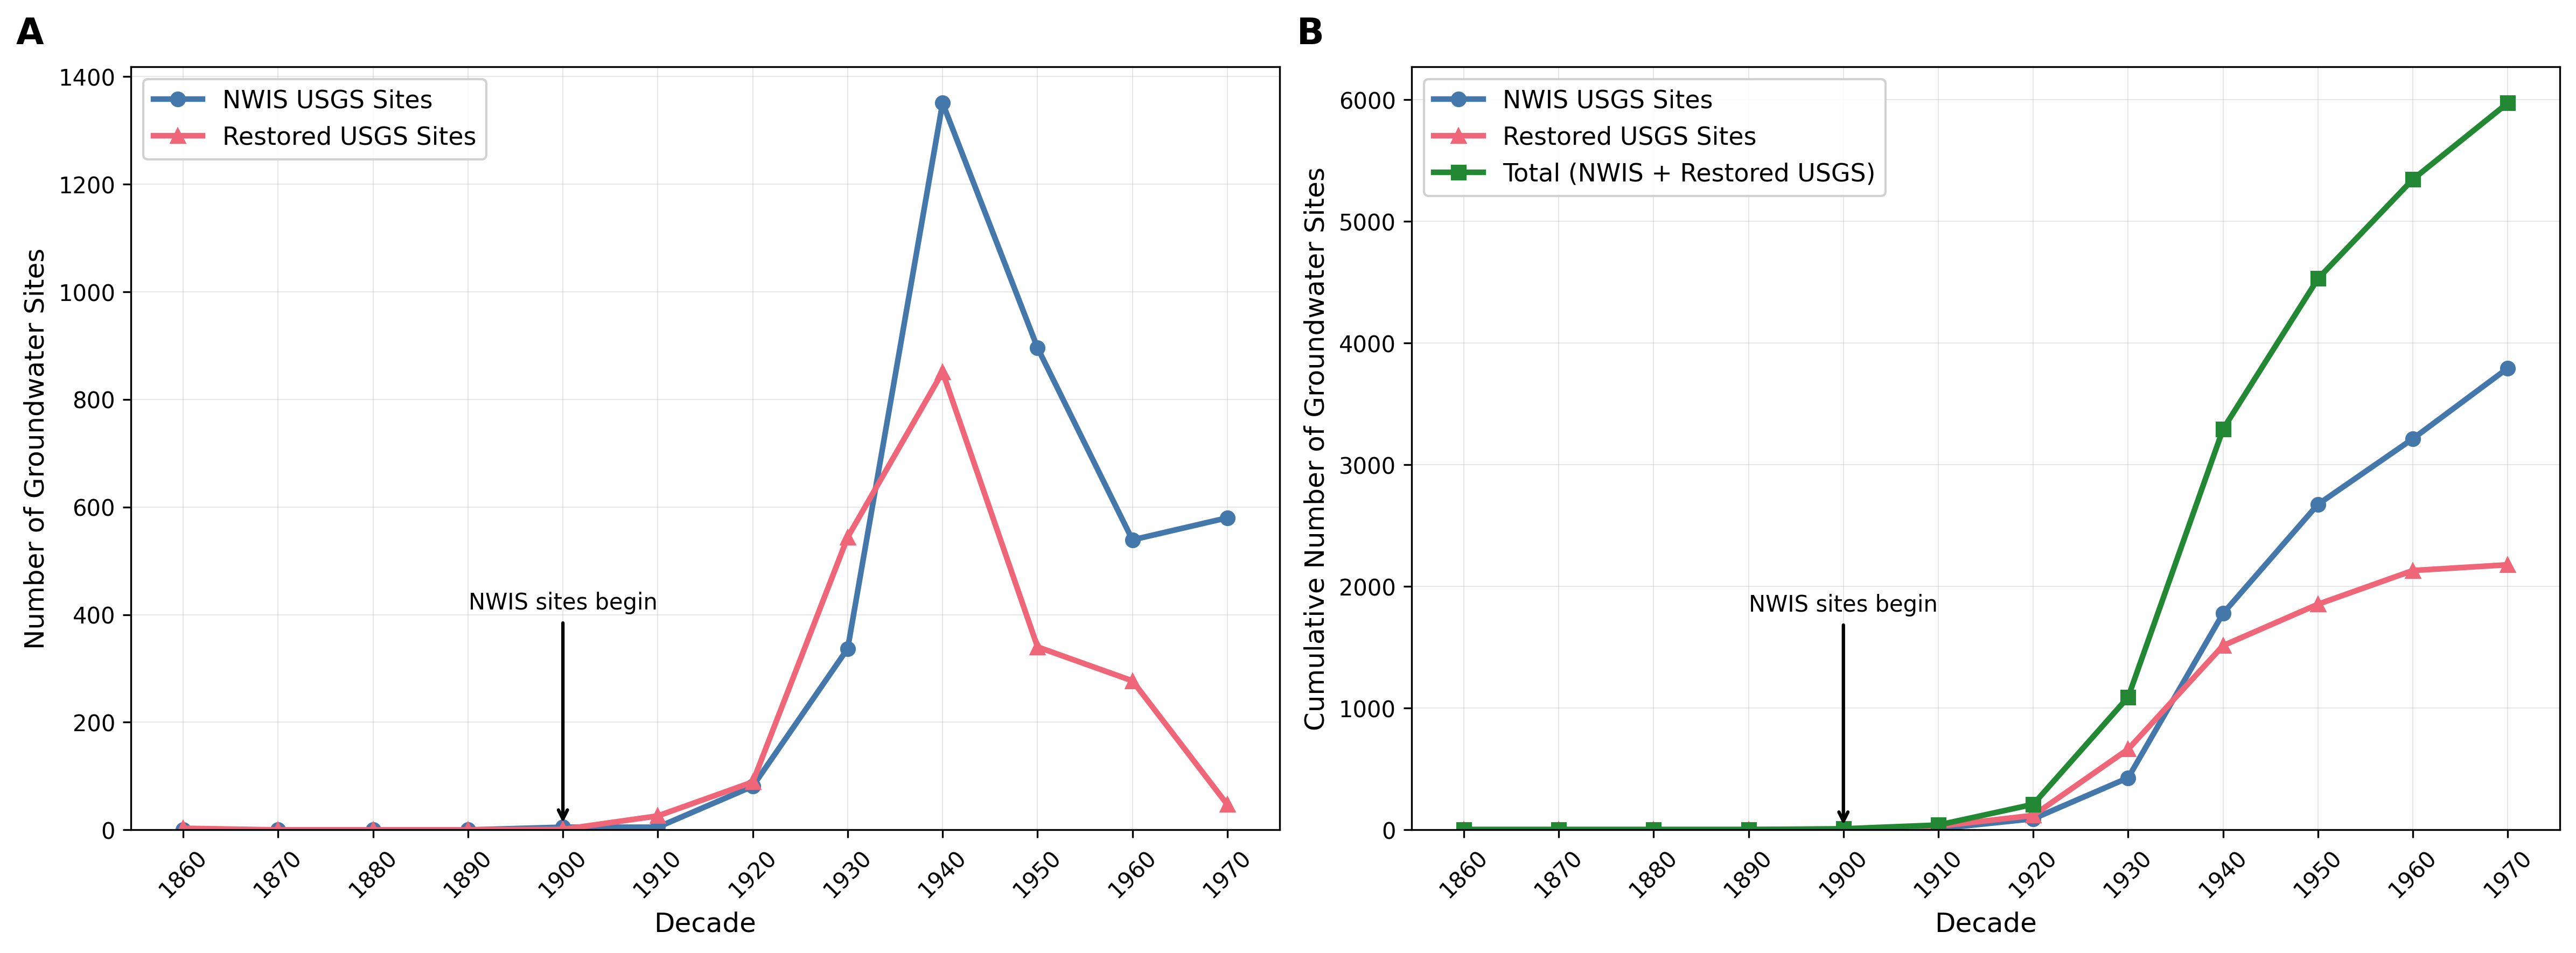


=== SUMMARY STATISTICS ===
Per-decade counts:
Decade  NWIS USGS  Restored USGS
  1860          0              3
  1870          0              0
  1880          0              0
  1890          0              0
  1900          5              1
  1910          5             26
  1920         81             89
  1930        337            544
  1940       1351            851
  1950        896            340
  1960        539            277
  1970        580             47

Cumulative totals:
Decade  NWIS USGS  Restored USGS  Total
  1860          0              3      3
  1870          0              3      3
  1880          0              3      3
  1890          0              3      3
  1900          5              4      9
  1910         10             30     40
  1920         91            119    210
  1930        428            663   1091
  1940       1779           1514   3293
  1950       2675           1854   4529
  1960       3214           2131   5345
  1970       3794       

In [14]:
# ==== Create Two-Panel Figure: Groundwater Sites Over Time ====
print("=== CREATING TWO-PANEL GROUNDWATER SITES TIMELINE ===")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use the same combined dataset from the previous script
if 'all_gw_data' in globals() and all_gw_data is not None:
    print("Using combined groundwater dataset from previous analysis...")
    
    # Define decade range (1860s to 1970s) - same as original script
    decades = list(range(1860, 1980, 10))
    
    # Count sites by decade and data type
    decade_counts = all_gw_data.groupby(['decade', 'data_type']).size().unstack(fill_value=0)
    
    # Ensure all decades are represented (fill missing with 0)
    decade_counts = decade_counts.reindex(decades, fill_value=0)
    
    # Calculate cumulative counts
    nwis_cumulative = decade_counts['NWIS USGS'].cumsum() if 'NWIS USGS' in decade_counts.columns else pd.Series(0, index=decades)
    restored_cumulative = decade_counts['Restored USGS'].cumsum() if 'Restored USGS' in decade_counts.columns else pd.Series(0, index=decades)
    total_cumulative = nwis_cumulative + restored_cumulative
    
    # Get non-cumulative counts (actual counts per decade)
    nwis_counts = decade_counts['NWIS USGS'] if 'NWIS USGS' in decade_counts.columns else pd.Series(0, index=decades)
    restored_counts = decade_counts['Restored USGS'] if 'Restored USGS' in decade_counts.columns else pd.Series(0, index=decades)
    
    # Use the same color palette from the original script
    colors = {
        'NWIS USGS': '#4477AA',      # Blue
        'Restored USGS': '#EE6677',  # Red
        'Total': '#228833'           # Green for total
    }
    
    # Create the two-panel figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
    
    # ==== PANEL A: NON-CUMULATIVE COUNTS ====
    # Plot the lines for actual counts per decade
    ax1.plot(decades, nwis_counts, 
             color=colors['NWIS USGS'], 
             linewidth=2.5, 
             marker='o', 
             markersize=6,
             label='NWIS USGS Sites')
    
    ax1.plot(decades, restored_counts, 
             color=colors['Restored USGS'], 
             linewidth=2.5, 
             marker='^', 
             markersize=6,
             label='Restored USGS Sites')
    
    # Formatting for Panel A
    ax1.set_xlabel('Decade', fontsize=12)
    ax1.set_ylabel('Number of Groundwater Sites', fontsize=12)
    
    # Set x-axis ticks
    ax1.set_xticks(decades)
    ax1.set_xticklabels([str(d) for d in decades], rotation=45)
    
    # Grid and styling
    ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax1.set_axisbelow(True)
    ax1.legend(loc='upper left', fontsize=11, framealpha=0.9)
    ax1.set_ylim(bottom=0)
    
    # Add annotation for NWIS start (Panel A)
    nwis_start_decade_a = None
    for decade in decades:
        if nwis_counts[decade] > 0:
            nwis_start_decade_a = decade
            break
    
    if nwis_start_decade_a is not None:
        y_value_a = nwis_counts[nwis_start_decade_a]
        ax1.annotate('NWIS sites begin', 
                    xy=(nwis_start_decade_a, y_value_a),
                    xytext=(nwis_start_decade_a, y_value_a + max(max(nwis_counts), max(restored_counts)) * 0.3),
                    fontsize=10,
                    ha='center',
                    arrowprops=dict(arrowstyle='->', 
                                  color='black',
                                  lw=1.5))
    
    # Panel A label
    ax1.text(-0.1, 1.02, 'A', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='bottom')
    
    # ==== PANEL B: CUMULATIVE COUNTS ====
    # Plot the lines
    ax2.plot(decades, nwis_cumulative, 
            color=colors['NWIS USGS'], 
            linewidth=2.5, 
            marker='o', 
            markersize=6,
            label='NWIS USGS Sites')
    
    ax2.plot(decades, restored_cumulative, 
            color=colors['Restored USGS'], 
            linewidth=2.5, 
            marker='^', 
            markersize=6,
            label='Restored USGS Sites')
    
    ax2.plot(decades, total_cumulative, 
            color=colors['Total'], 
            linewidth=2.5, 
            marker='s', 
            markersize=6,
            label='Total (NWIS + Restored USGS)')
    
    # Formatting for Panel B
    ax2.set_xlabel('Decade', fontsize=12)
    ax2.set_ylabel('Cumulative Number of Groundwater Sites', fontsize=12)
    
    # Set x-axis ticks
    ax2.set_xticks(decades)
    ax2.set_xticklabels([str(d) for d in decades], rotation=45)
    
    # Grid and styling
    ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax2.set_axisbelow(True)
    ax2.legend(loc='upper left', fontsize=11, framealpha=0.9)
    ax2.set_ylim(bottom=0)
    
    # Add annotation for NWIS start (Panel B)
    nwis_start_decade_b = None
    for decade in decades:
        if nwis_cumulative[decade] > 0:
            nwis_start_decade_b = decade
            break
    
    if nwis_start_decade_b is not None:
        y_value_b = nwis_cumulative[nwis_start_decade_b]
        ax2.annotate('NWIS sites begin', 
                   xy=(nwis_start_decade_b, y_value_b),
                   xytext=(nwis_start_decade_b, y_value_b + max(total_cumulative) * 0.3),
                   fontsize=10,
                   ha='center',
                   arrowprops=dict(arrowstyle='->', 
                                 color='black',
                                 lw=1.5))
    
    # Panel B label
    ax2.text(-0.1, 1.02, 'B', transform=ax2.transAxes, fontsize=16, fontweight='bold', va='bottom')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the combined plot
    from pathlib import Path
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    
    outfile = output_dir / "groundwater_sites_two_panel.png"
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    print(f"Saved two-panel figure: {outfile}")
    
    plt.show()
    
    # Print summary statistics
    print(f"\n=== SUMMARY STATISTICS ===")
    print("Per-decade counts:")
    decade_summary_df = pd.DataFrame({
        'Decade': [str(d) for d in decades],
        'NWIS USGS': nwis_counts.values,
        'Restored USGS': restored_counts.values
    })
    print(decade_summary_df.to_string(index=False))
    
    print(f"\nCumulative totals:")
    cumulative_summary_df = pd.DataFrame({
        'Decade': [str(d) for d in decades],
        'NWIS USGS': nwis_cumulative.values,
        'Restored USGS': restored_cumulative.values,
        'Total': total_cumulative.values
    })
    print(cumulative_summary_df.to_string(index=False))
    
    print(f"\nFinal totals:")
    print(f"  NWIS USGS sites: {nwis_cumulative.iloc[-1]:,}")
    print(f"  Restored USGS sites: {restored_cumulative.iloc[-1]:,}")
    print(f"  Total sites: {total_cumulative.iloc[-1]:,}")

else:
    print("ERROR: Combined groundwater dataset not found. Please run the previous script first.")
    print("Make sure 'all_gw_data' variable is available from the previous analysis.")